In [1]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from gena_expression.conditions import Condition, DescriptionLookup
from gena_expression.genome import Genome
from gena_expression.models import SequenceModel

In [ ]:
# Paths and constants used by later cells

from pathlib import Path

GENA_LM_ROOT = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark") / "GENA_LM" # CHANGE THIS LINE

EXPRESSION_TASK_DIR = GENA_LM_ROOT / "downstream_tasks" / "expression_prediction"

MODEL_CLS = EXPRESSION_TASK_DIR / "expression_model_final.py"
MODEL_CLS = f"{MODEL_CLS}::ExpressionCounts"

MODEL_CHECKPOINT = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark") / "models" / "expression_model" / "pytorch_model.bin" # CHANGE THIS LINE
MODEL_CONFIG = EXPRESSION_TASK_DIR / "inference_example_config.yaml" # CHANGE THIS LINE
DNA_TOKENIZER = GENA_LM_ROOT / "data" / "tokenizers" / "t2t_1000h_multi_32k"
DESCRIPTION_TOKENIZER = "Qwen/Qwen3-Embedding-0.6B"

DATA_DIR = Path("../data").resolve()
DESCRIPTION_DIR = DATA_DIR / "real_descriptions"

GENOME_FASTA = Path("/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa") # CHANGE THIS LINE
GENOME_ANNOTATION = Path(
    "/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/"
    "downstream_tasks/expression_prediction/datasets/data/genomes/hg38/"
    "gencode.v29.primary_assembly.annotation_UCSC_names.gtf"
) # CHANGE THIS LINE

DEVICE = "cuda:5"
os.environ["GENALM_HOME"] = Path('../../../../..').resolve().__str__() # CHANGE THIS LINE

## Load the expression prediction model

Here we load the GENA-LM expression model through the API wrapper. The wrapper handles the model class import, checkpoint loading, Hydra config, DNA tokenizer, description tokenizer, and device placement.

The DNA-side parameters define how genomic sequence is tokenized around a biological center:

- `dna_max_seq_len=1024`: maximum number of DNA tokens including special tokens.
- `num_before=511`: number of DNA tokens kept upstream of the center.
- `token_len_for_fetch=9`: approximate nucleotide span used when fetching sequence before tokenization.
- `desc_max_seq_len=510`: maximum length for metadata / experiment-description tokens.

This setup uses centered tokenization, so it is intended for coordinate-aware API inference rather than exact reproduction of the original notebook's plain full-sequence tokenization.

In [3]:
model = SequenceModel.load(
    model_cls=MODEL_CLS,
    checkpoint=MODEL_CHECKPOINT,
    config=MODEL_CONFIG,
    dna_tokenizer=DNA_TOKENIZER,
    description_tokenizer=DESCRIPTION_TOKENIZER,
    dna_max_seq_len=1024,
    num_before=511,
    desc_max_seq_len=510,
    token_len_for_fetch=9,
    device=DEVICE,
)

/home/jovyan/miniconda3/envs/api/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/models.py:140: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from AIRI-Institute/moderngena-large


Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", torch_dtype=torch.float16)`


missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_proj.weight
  - layers.25.self_attn.k_proj.weight
  - layers.25.self_attn.v_proj.weight
  - l

## Select experiment descriptions

`DescriptionLookup` reads metadata JSON files and deterministically selects one metadata record per requested cell type.

Here we explicitly pin each cell type to a known metadata file ID:

- `K562` -> `ENCFF578UUD`
- `HepG2` -> `ENCFF588KDY`
- `H1` -> `ENCFF081FQX`

The selected metadata records are later converted into natural-language descriptions and passed through the text tokenizer.

In [4]:
lookup = DescriptionLookup(
    json_dir=DESCRIPTION_DIR,
    keys=["K562", "HepG2", "H1"],
    K562={"id": "ENCFF578UUD"},
    HepG2={"id": "ENCFF588KDY"},
    H1={"id": "ENCFF081FQX"},
)

## Load the genome and annotations

`Genome` provides FASTA-backed sequence retrieval. We also pass a GTF annotation file, so fetched sequences can carry genomic feature annotations such as genes, transcripts, and exons.

Coordinates used by the API are 0-based by default. The annotation loader converts GTF's 1-based inclusive coordinates into internal 0-based half-open intervals.

In [5]:
genome = Genome(
    fasta_path=GENOME_FASTA,
    annotation=GENOME_ANNOTATION,
)

tss_coords = {
    "Sox2": ('chr3', 181711924, '+'),
    "Nanog": ('chr12', 7789414, '+'),
    "HBB": ('chr11', 5227072, '-'),
    'ALB': ('chr4', 73404239, '+')
	   }

(<Figure size 700x1000 with 4 Axes>,
 <Axes: title={'center': 'Annotated sequence'}, xlabel='Sequence coordinate'>)

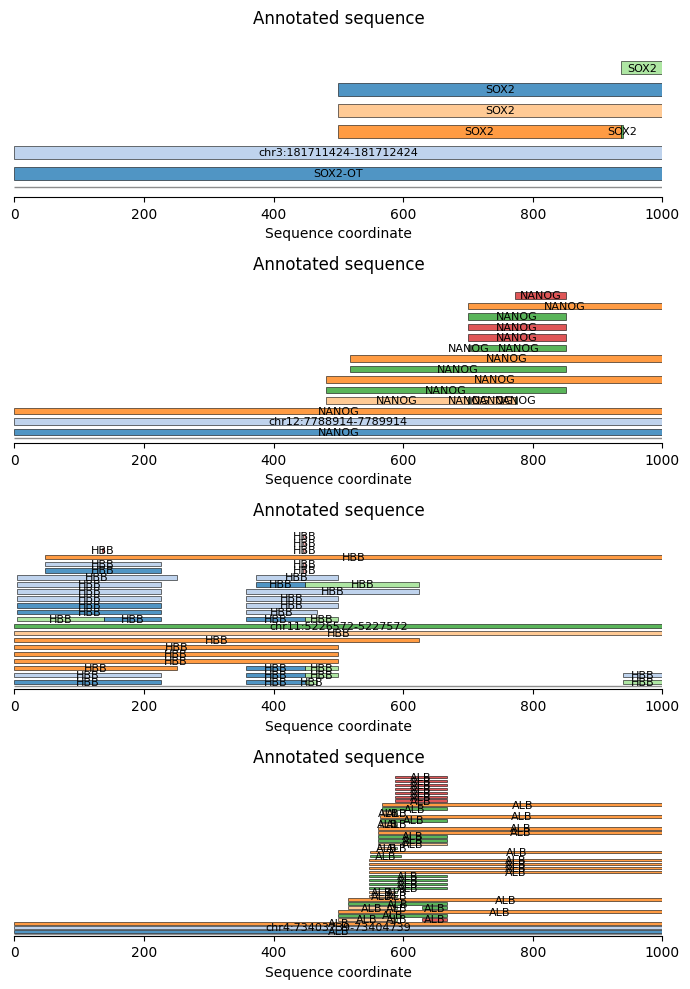

In [6]:
#make sure that TSS is always in the middle
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(7,10))
#plot sox2
Sox2_chrom, Sox2_interval_start, Sox2_interval_end = tss_coords['Sox2'][0], tss_coords['Sox2'][1]-500, tss_coords['Sox2'][1]+500
genome.sequence(Sox2_chrom, Sox2_interval_start, Sox2_interval_end).plot_annotations(ax=axs[0], show_legend=False, hide_types=('source', 'transcript'))
#plot nanog
Nanog_chrom, Nanog_interval_start, Nanog_interval_end = tss_coords['Nanog'][0], tss_coords['Nanog'][1]-500, tss_coords['Nanog'][1]+500
genome.sequence(Nanog_chrom, Nanog_interval_start, Nanog_interval_end).plot_annotations(ax=axs[1], show_legend=False)
#plot HBB
HBB_chrom, HBB_interval_start, HBB_interval_end = tss_coords['HBB'][0], tss_coords['HBB'][1]-500, tss_coords['HBB'][1]+500
genome.sequence(HBB_chrom, HBB_interval_start, HBB_interval_end).plot_annotations(ax=axs[2], show_legend=False)
#plot ALB
ALB_chrom, ALB_interval_start, ALB_interval_end = tss_coords['ALB'][0], tss_coords['ALB'][1]-500, tss_coords['ALB'][1]+500
genome.sequence(ALB_chrom, ALB_interval_start, ALB_interval_end).plot_annotations(ax=axs[3], show_legend=False)

For every `(cell type, gene)` pair, we fetch a 20 kb sequence centered on the gene's TSS, tokenize it around the TSS, and predict expression under the selected cell-type condition.

Important arguments:

- `genome`: FASTA-backed genome object.
- `chrom`, `tss`, `strand`: genomic TSS definition.
- `condition`: metadata record selected by `DescriptionLookup`.
- `coordinate_system="0-based"`: tells the API that TSS coordinates are already 0-based.
- `dataset_flag=0`: matches the model's inference mode where one description is repeated across multiple DNA inputs.
- `context_bp=20000`: fetches a 20 kb window around the TSS.

The output is a predicted expression value, interpreted as `log(TPM + 1)`.

In [7]:
results = []
for cell_type in lookup.keys():
    for gene in tss_coords.keys():
        expression = model.predict_expression_at_tss(genome=genome, 
                                        tss=tss_coords[gene][1], 
                                        chrom=tss_coords[gene][0], 
                                        strand=tss_coords[gene][2],
                                        condition=lookup[cell_type],
                                        coordinate_system='0-based',
                                        dataset_flag=0,
                                        context_bp=20000).expression
        results.append(
            (cell_type, gene, expression)
        )

Casting fp32 inputs back to torch.float16 for flash-attn compatibility.


The bar plot compares predicted expression across genes and cell types.

Expected qualitative behavior:

- `ALB` should be high in the liver-derived `HepG2` condition.
- `HBB` should be higher in the blood-related `K562` condition.
- pluripotency-associated genes such as `Sox2` and `Nanog` should be more active in the embryonic stem cell condition `H1`.

In [8]:
def plot_results(results:list):
    df = pd.DataFrame(results)
    df.columns = ['Cell Type', 'Gene', 'Expression']
    print (df)
    plt.figure(figsize=(2.5, 5))
    sns.barplot(x='Gene', y='Expression', hue='Cell Type', data=df, palette='gray')
    plt.xlabel('Gene', fontsize=12)
    plt.ylabel('Expression (log(TPM+1))', fontsize=12)
    plt.grid(True, axis='y')
    plt.show()

   Cell Type   Gene  Expression
0       K562   Sox2    0.059998
1       K562  Nanog    0.129883
2       K562    HBB    1.024414
3       K562    ALB    0.151733
4      HepG2   Sox2    0.241699
5      HepG2  Nanog    0.050995
6      HepG2    HBB    0.072510
7      HepG2    ALB    9.320312
8         H1   Sox2    2.636719
9         H1  Nanog    1.333984
10        H1    HBB    0.029358
11        H1    ALB    0.137451


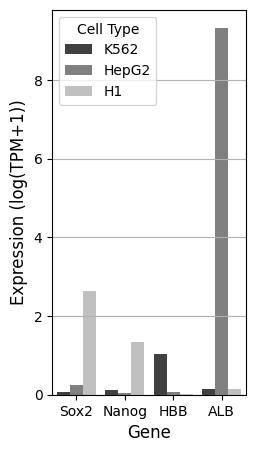

In [8]:
plot_results(results)

## Batch Inference

The single-record loop above is simple, but it repeats tokenization/model work.  
The API has batch helpers for the common case where many DNA sequences are scored under repeated or shared conditions.

There are three useful patterns:

1. **Many DNA sequences, one description**: efficient when we compare several genes in one cell type.
2. **One DNA sequence, many descriptions**: efficient when we compare one gene across many cell types.
3. **Many TSS records and many conditions**: high-level API; records and conditions are paired row-wise, and repeated conditions are grouped internally.

In [9]:
conditions = {
    cell_type: Condition(name=cell_type, description=lookup[cell_type])
    for cell_type in lookup.keys()
}

tss_records = [
    {
        "name": gene,
        "chrom": chrom,
        "tss": tss,
        "strand": strand,
    }
    for gene, (chrom, tss, strand) in tss_coords.items()
]

tss_records

[{'name': 'Sox2', 'chrom': 'chr3', 'tss': 181711924, 'strand': '+'},
 {'name': 'Nanog', 'chrom': 'chr12', 'tss': 7789414, 'strand': '+'},
 {'name': 'HBB', 'chrom': 'chr11', 'tss': 5227072, 'strand': '-'},
 {'name': 'ALB', 'chrom': 'chr4', 'tss': 73404239, 'strand': '+'}]

### Low-Level Batch: One Description, Many DNA Sequences

Here we fetch the TSS-centered sequences ourselves, then call `predict_many_sequences_one_condition`.  
This path uses the model optimization where the description embedding is computed once and reused for all DNA sequences in the batch.

In [16]:
# Build TSS-centered sequences once.
tss_sequences = [
    genome.sequence_around(
        record["chrom"],
        record["tss"],
        20_000,
        strand=record["strand"],
        include_features=True,
        center_feature_name="tss",
        name=record["name"],
    )
    for record in tss_records
]
results = []
for cell_type in conditions:
    
    preds_one_desc_many_dna = model.predict_many_sequences_one_condition(
        tss_sequences,
        condition=conditions[cell_type],
        center="tss",
        batch_size=4,
        return_tokens=True,
    )
    [results.append((p.condition.name, p.sequence.name, float(p.outputs["expression"].flatten()[0]))) for p in preds_one_desc_many_dna]

   Cell Type   Gene  Expression
0       K562   Sox2    0.060791
1       K562  Nanog    0.128906
2       K562    HBB    1.021484
3       K562    ALB    0.150635
4      HepG2   Sox2    0.243530
5      HepG2  Nanog    0.051819
6      HepG2    HBB    0.072693
7      HepG2    ALB    9.320312
8         H1   Sox2    2.636719
9         H1  Nanog    1.332031
10        H1    HBB    0.029236
11        H1    ALB    0.137329


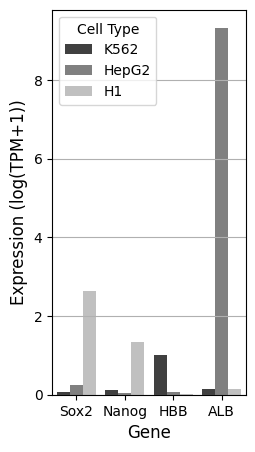

In [17]:
plot_results(results)

## One Sequence, Many Conditions

This example predicts expression for one TSS-centered gene sequence across several cell-type descriptions.  
This uses the optimized `predict_one_sequence_many_conditions(...)` path: the DNA sequence is encoded once, while descriptions are evaluated as a batch.

In [12]:
conditions = {
    cell_type: Condition(name=cell_type, description=lookup[cell_type])
    for cell_type in lookup.keys()
}

results = []

for gene, (chrom, tss, strand) in tss_coords.items():
    sequence = genome.sequence_around(
        chrom,
        tss,
        20_000,
        strand=strand,
        include_features=True,
        center_feature_name="tss",
        name=gene,
    )

    batch_conditions = [
        conditions[cell_type]
        for cell_type in lookup.keys()
    ]

    batch_predictions = model.predict_one_sequence_many_conditions(
        sequence=sequence,
        conditions=batch_conditions,
        center="tss",
        batch_size=4,
        return_tokens=True,
    )

    for batch_prediction in batch_predictions:
        results.append(
            (
                batch_prediction.condition.name,
                batch_prediction.sequence.name,
                float(batch_prediction.outputs["expression"].flatten()[0]),
            )
        )


   Cell Type   Gene  Expression
0       K562   Sox2    0.061096
1      HepG2   Sox2    0.241943
2         H1   Sox2    2.636719
3       K562  Nanog    0.129272
4      HepG2  Nanog    0.052307
5         H1  Nanog    1.335938
6       K562    HBB    1.024414
7      HepG2    HBB    0.072571
8         H1    HBB    0.029800
9       K562    ALB    0.150757
10     HepG2    ALB    9.320312
11        H1    ALB    0.137573


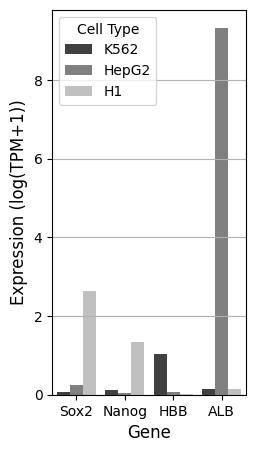

In [13]:
plot_results(results)

### High-Level Batch: Many TSS Records and Many Conditions

`predict_expression_at_tss_many` is the recommended notebook-facing API.  
It accepts TSS records and conditions row-wise. If the same condition appears multiple times, the API groups those records internally and uses the efficient "many DNA, one description" batch path.

Here we reproduce the same full grid as the loop: 4 genes × 3 cell types.

In [14]:
batch_records = []
batch_conditions = []

for cell_type in lookup.keys():
    for gene, (chrom, tss, strand) in tss_coords.items():
        batch_records.append(
            {
                "name": gene,
                "chrom": chrom,
                "tss": tss,
                "strand": strand,
            }
        )
        batch_conditions.append(conditions[cell_type])

batch_predictions = model.predict_expression_at_tss_many(
    records=batch_records,
    conditions=batch_conditions,
    genome=genome,
    context_bp=20_000,
    coordinate_system="0-based",
    include_features=True,
    center_feature_name="tss",
    batch_size=4,
)
results = []
for batch_prediction in batch_predictions:
    results.append(
        (batch_prediction.condition.name, batch_prediction.sequence.name, batch_prediction.expression)
    )

   Cell Type   Gene  Expression
0       K562   Sox2    0.060791
1       K562  Nanog    0.128906
2       K562    HBB    1.021484
3       K562    ALB    0.150635
4      HepG2   Sox2    0.243530
5      HepG2  Nanog    0.051819
6      HepG2    HBB    0.072693
7      HepG2    ALB    9.320312
8         H1   Sox2    2.636719
9         H1  Nanog    1.332031
10        H1    HBB    0.029236
11        H1    ALB    0.137329


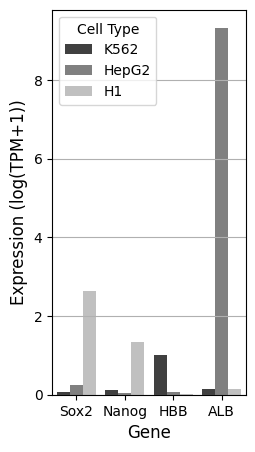

In [15]:
plot_results(results)